# 결측치 처리하기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False


In [2]:
df = pd.read_csv('pandas/data/california_housing_test.csv')
df['RID'] = df.index
df = df[['RID'] + [col for col in df.columns if col != 'RID']]
df.head()

,RID,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0
1,1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0
2,2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0
3,3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0
4,4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RID                 3000 non-null   int64  
 1   longitude           3000 non-null   float64
 2   latitude            3000 non-null   float64
 3   housing_median_age  3000 non-null   float64
 4   total_rooms         3000 non-null   float64
 5   total_bedrooms      3000 non-null   float64
 6   population          3000 non-null   float64
 7   households          3000 non-null   float64
 8   median_income       3000 non-null   float64
 9   median_house_value  3000 non-null   float64
dtypes: float64(9), int64(1)
memory usage: 234.5 KB


In [4]:
# === 랜덤 결측치 생성 ===
# 원본 데이터를 보존하기 위해 복사본(df_missing)을 만들어서 작업
df_missing = df.copy()

# 재현 가능한 결과를 위해 랜덤 시드 고정
np.random.seed(42)

# 전체 데이터의 10% (300개)를 랜덤으로 선택하여 결측치로 변환
missing_ratio = 0.10  # 결측치 비율: 10%
n_missing = int(len(df_missing) * missing_ratio)  # 결측치 개수 계산

# 중복 없이 랜덤 인덱스를 선택 (replace=False: 같은 인덱스 중복 선택 방지)
missing_indices = np.random.choice(df_missing.index, size=n_missing, replace=False)

# 원본 값을 별도로 저장 (나중에 복원 정확도 비교용)
original_values = df_missing.loc[missing_indices, 'median_house_value'].copy()

# 선택된 인덱스의 median_house_value를 NaN으로 변환
df_missing.loc[missing_indices, 'median_house_value'] = np.nan

print(f"=== 결측치 생성 완료 ===")
print(f"전체 데이터 수: {len(df_missing)}개")
print(f"생성된 결측치 수: {n_missing}개 ({missing_ratio*100:.0f}%)")
print(f"결측치가 아닌 데이터 수: {df_missing['median_house_value'].notna().sum()}개")
print()

# 필요없는 컬럼 제거하기
df_missing.drop([df_missing.columns[0]], axis=1, inplace=True)

# 결측치가 포함된 데이터 확인 (상위 10개)
print("=== 결측치가 포함된 행 (상위 10개) ===")
df_missing[df_missing['median_house_value'].isna()].head(10)

=== 결측치 생성 완료 ===
전체 데이터 수: 3000개
생성된 결측치 수: 300개 (10%)
결측치가 아닌 데이터 수: 2700개

=== 결측치가 포함된 행 (상위 10개) ===


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,NaN
14,-117.97,33.73,27.0,2097.0,325.0,1217.0,331.0,5.7121,NaN
30,-119.35,36.33,14.0,1195.0,220.0,568.0,229.0,3.1486,NaN
32,-121.13,39.31,17.0,3442.0,705.0,1693.0,619.0,2.8102,NaN
44,-118.23,34.13,48.0,1308.0,286.0,835.0,294.0,4.2891,NaN
45,-117.24,33.17,4.0,9998.0,1874.0,3925.0,1672.0,4.2826,NaN
51,-119.42,35.97,21.0,554.0,121.0,426.0,122.0,2.3516,NaN
52,-122.21,37.80,39.0,2003.0,500.0,1109.0,464.0,3.0682,NaN
63,-121.67,40.87,31.0,1581.0,299.0,776.0,287.0,2.9063,NaN
67,-117.53,33.92,12.0,2290.0,319.0,728.0,228.0,6.1561,NaN


In [5]:
# info() 메소드 ---> index범위, 컬럼정보, 컬럼 수, 컬럼 명, 컬럼별 non-null수, 컬럼 데이터 타입
# index범위와 특정 컬럼명의 컬럼별 non-null수를 비교하여 결측치 확인가능
df_missing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           3000 non-null   float64
 1   latitude            3000 non-null   float64
 2   housing_median_age  3000 non-null   float64
 3   total_rooms         3000 non-null   float64
 4   total_bedrooms      3000 non-null   float64
 5   population          3000 non-null   float64
 6   households          3000 non-null   float64
 7   median_income       3000 non-null   float64
 8   median_house_value  2700 non-null   float64
dtypes: float64(9)
memory usage: 211.1 KB


In [6]:
# df_missing의 isnull()메소드는 결측치가 있으면 해당 컬럼에 True, 결측치가 아니면 False를 반환한다.
# 이를 이용하여 컬럼별 합계(True == 1, axis=0)를 구하여 결측치를 직관적으로 확인가능하다.
df_missing.isnull().sum(axis=0)

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms          0
population              0
households              0
median_income           0
median_house_value    300
dtype: int64

=== 방법 1: 컬럼별 결측치 개수 (isnull().sum()) ===
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms          0
population              0
households              0
median_income           0
median_house_value    300
dtype: int64

=== 방법 2: 데이터프레임 정보 (info()) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           3000 non-null   float64
 1   latitude            3000 non-null   float64
 2   housing_median_age  3000 non-null   float64
 3   total_rooms         3000 non-null   float64
 4   total_bedrooms      3000 non-null   float64
 5   population          3000 non-null   float64
 6   households          3000 non-null   float64
 7   median_income       3000 non-null   float64
 8   median_house_value  2700 non-null   float64
dtypes: float64(9)
memory usage:

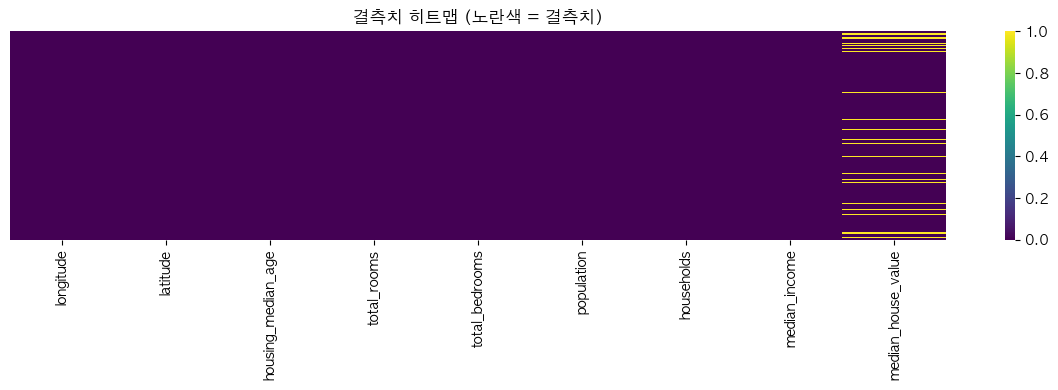

In [7]:
# === 결측치 확인 방법 모음 ===

# 방법 1: isnull().sum() - 각 컬럼별 결측치 개수 확인 (가장 기본)
print("=== 방법 1: 컬럼별 결측치 개수 (isnull().sum()) ===")
print(df_missing.isnull().sum())
print()

# 방법 2: info() - 데이터프레임 전체 정보 (Non-Null Count로 결측치 유추 가능)
print("=== 방법 2: 데이터프레임 정보 (info()) ===")
df_missing.info()
print()

# 방법 3: 결측치 비율을 퍼센트로 확인 (실무에서 매우 유용)
print("=== 방법 3: 컬럼별 결측치 비율 (%) ===")
missing_pct = (df_missing.isnull().sum() / len(df_missing) * 100).round(2)
print(missing_pct[missing_pct > 0])  # 결측치가 있는 컬럼만 출력
print()

# 방법 4: 결측치 시각화 (히트맵) - 결측치 패턴을 한눈에 파악
plt.figure(figsize=(12, 4))
# isnull() 결과를 히트맵으로 표시: 노란색=결측치, 보라색=정상값
sns.heatmap(df_missing.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('결측치 히트맵 (노란색 = 결측치)')
plt.tight_layout()
plt.show()

In [14]:
# 방법1. 결측치 삭제하기

df_na = df_missing.copy()
'''
옵션         의미
how='all'   행의 모든 값이 NaN일 때만 삭제
how='any'	행에 NaN이 하나라도 있으면 삭제, default
'''
df_na = df_na.dropna()   
df_na.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2700 entries, 1 to 2999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           2700 non-null   float64
 1   latitude            2700 non-null   float64
 2   housing_median_age  2700 non-null   float64
 3   total_rooms         2700 non-null   float64
 4   total_bedrooms      2700 non-null   float64
 5   population          2700 non-null   float64
 6   households          2700 non-null   float64
 7   median_income       2700 non-null   float64
 8   median_house_value  2700 non-null   float64
dtypes: float64(9)
memory usage: 210.9 KB


In [15]:
print(f"삭제 전 데이터 수: {len(df_missing)}개")
print(f"삭제 후 데이터 수: {len(df_na)}개")
print(f"삭제된 행 수: {len(df_missing) - len(df_na)}개")
print()

# 삭제 후 기초 통계량 비교
print("=== 원본 vs 삭제 후 기초 통계량 비교 ===")
comparison = pd.DataFrame({
    '원본': df['median_house_value'].describe(),
    '삭제 후': df_na['median_house_value'].describe()
})
comparison['차이'] = comparison['삭제 후'] - comparison['원본']
comparison.round(2)

삭제 전 데이터 수: 3000개
삭제 후 데이터 수: 2700개
삭제된 행 수: 300개

=== 원본 vs 삭제 후 기초 통계량 비교 ===


,원본,삭제 후,차이
count,3000.00,2700.00,-300.00
mean,205846.28,205559.86,-286.42
std,113119.69,112849.86,-269.82
min,22500.00,37500.00,15000.00
25%,121200.00,120700.00,-500.00
50%,177650.00,178100.00,450.00
75%,263975.00,264550.00,575.00
max,500001.00,500001.00,0.00


In [20]:
# === 방법 2: 평균(mean)으로 대체 ===
df_mean = df_missing.copy()
# 결측치가 아닌 값들의 평균을 계산하여 결측치를 채움
mean_value = df_mean['median_house_value'].mean()
df_mean['median_house_value'] = df_mean['median_house_value'].fillna(mean_value)

print(f"평균값으로 대체: {mean_value:,.0f}")
print()

# === 방법 3: 중앙값(median)으로 대체 ===
df_median = df_missing.copy()
# 중앙값: 데이터를 크기순으로 나열했을 때 정중앙에 위치한 값
median_value = df_median['median_house_value'].median()
df_median['median_house_value'] = df_median['median_house_value'].fillna(median_value)

print(f"중앙값으로 대체: {median_value:,.0f}")
print()

# === 방법 4: 최빈값(mode)으로 대체 ===
df_mode = df_missing.copy()
# mode()는 여러 개의 최빈값을 반환할 수 있으므로 [0]으로 첫 번째 값 선택
mode_value = df_mode['median_house_value'].mode()[0]
df_mode['median_house_value'] = df_mode['median_house_value'].fillna(mode_value)

print(f"최빈값으로 대체: {mode_value:,.0f}")
print()

# 세 가지 방법 비교
print("=== 대체 방법별 기초 통계량 비교 ===")
comparison = pd.DataFrame({
    '원본': df['median_house_value'].describe(),
    '평균 대체': df_mean['median_house_value'].describe(),
    '중앙값 대체': df_median['median_house_value'].describe(),
    '최빈값 대체': df_mode['median_house_value'].describe()
}).round(2)
comparison

평균값으로 대체: 205,560

중앙값으로 대체: 178,100

최빈값으로 대체: 500,001

=== 대체 방법별 기초 통계량 비교 ===


,원본,평균 대체,중앙값 대체,최빈값 대체
count,3000.00,3000.00,3000.00,3000.00
mean,205846.28,205559.86,202813.87,235003.97
std,113119.69,107056.80,107373.39,138803.32
min,22500.00,37500.00,37500.00,37500.00
25%,121200.00,129175.00,129175.00,129175.00
50%,177650.00,192200.00,178100.00,192200.00
75%,263975.00,250000.00,250000.00,309925.00
max,500001.00,500001.00,500001.00,500001.00


In [22]:
# === 방법 5: 앞/뒤 값으로 채우기 (ffill / bfill) ===

# ffill (Forward Fill): 바로 앞의 유효한 값으로 채움
# 예: [100, NaN, NaN, 200] → [100, 100, 100, 200]
df_ffill = df_missing.copy()
df_ffill['median_house_value'] = df_ffill['median_house_value'].ffill()

# bfill (Backward Fill): 바로 뒤의 유효한 값으로 채움
# 예: [100, NaN, NaN, 200] → [100, 200, 200, 200]
df_bfill = df_missing.copy()
df_bfill['median_house_value'] = df_bfill['median_house_value'].bfill()

print("=== ffill vs bfill 결과 비교 (결측치였던 위치의 값) ===")
comparison_fb = pd.DataFrame({
    '원본값': original_values,
    'ffill 대체값': df_ffill.loc[missing_indices, 'median_house_value'],
    'bfill 대체값': df_bfill.loc[missing_indices, 'median_house_value']
})
comparison_fb



=== ffill vs bfill 결과 비교 (결측치였던 위치의 값) ===


,원본값,ffill 대체값,bfill 대체값
1801,119400.0,95800.0,213200.0
1190,133600.0,243800.0,228600.0
1817,173600.0,156300.0,206300.0
251,218600.0,232700.0,135000.0
2505,276700.0,93100.0,174400.0
...,...,...,...
2497,500001.0,56000.0,47700.0
787,181000.0,372700.0,198100.0
2636,450000.0,124900.0,99700.0
2538,137500.0,450000.0,437100.0


In [23]:
# 남아있는 결측치 확인 (첫 번째 행이 결측치면 ffill로 채울 수 없음)
print(f"ffill 후 남은 결측치: {df_ffill['median_house_value'].isna().sum()}개")
print(f"bfill 후 남은 결측치: {df_bfill['median_house_value'].isna().sum()}개")

ffill 후 남은 결측치: 1개
bfill 후 남은 결측치: 0개


In [29]:
# === 방법 6: 그룹별 평균으로 대체 ===
df_group = df_missing.copy()

# housing_median_age를 10년 단위 구간으로 나누기
# pd.cut(): 연속형 변수를 범주형 구간으로 변환
# 예: 0~10, 10~20, 20~30, 30~40, 40~50, 50~60
df_group['age_group'] = pd.cut(df_group['housing_median_age'],
                                bins=[0, 10, 20, 30, 40, 50, 60],
                                labels=['0-10', '10-20', '20-30', '30-40', '40-50', '50-60'])

# 각 연령 구간별 median_house_value의 평균 확인
print("=== 연령 구간별 평균 집값 ===")
group_means = df_group.groupby('age_group', observed=False)['median_house_value'].mean()
print(group_means.apply(lambda x: f"{x:,.0f}"))

# transform(): 그룹별 연산 결과를 원래 데이터프레임 크기에 맞게 변환
# 각 행에 해당 그룹의 평균값이 매핑됨
group_mean_values = df_group.groupby('age_group', observed=False)['median_house_value'].transform('mean')
print(group_mean_values)

# 결측치를 해당 그룹의 평균으로 대체
df_group['median_house_value'] = df_group['median_house_value'].fillna(group_mean_values)

# 보조 컬럼 삭제 (분석에 불필요)
df_group = df_group.drop(columns=['age_group'])

print(f"그룹별 평균 대체 후 결측치: {df_group['median_house_value'].isna().sum()}개")
print()

# 원본과 비교
print("=== 그룹별 평균 대체 vs 전체 평균 대체 비교 ===")
comparison_group = pd.DataFrame({
    '원본': df['median_house_value'].describe(),
    '전체 평균 대체': df_mean['median_house_value'].describe(),
    '그룹별 평균 대체': df_group['median_house_value'].describe()
}).round(2)
comparison_group


=== 연령 구간별 평균 집값 ===
age_group
0-10     196,959
10-20    189,109
20-30    209,079
30-40    207,448
40-50    201,805
50-60    258,942
Name: median_house_value, dtype: object
0       209079.386646
1       201805.354749
2       209079.386646
3       209079.386646
4       189108.582215
            ...      
2995    209079.386646
2996    209079.386646
2997    196958.670157
2998    207447.620270
2999    201805.354749
Name: median_house_value, Length: 3000, dtype: float64
그룹별 평균 대체 후 결측치: 0개

=== 그룹별 평균 대체 vs 전체 평균 대체 비교 ===


,원본,전체 평균 대체,그룹별 평균 대체
count,3000.00,3000.00,3000.00
mean,205846.28,205559.86,205340.59
std,113119.69,107056.80,107154.38
min,22500.00,37500.00,37500.00
25%,121200.00,129175.00,129175.00
50%,177650.00,192200.00,189108.58
75%,263975.00,250000.00,252450.00
max,500001.00,500001.00,500001.00


In [30]:
# === 방법 7: 보간법 (Interpolation) ===

# 선형 보간: 앞뒤 값 사이를 직선으로 연결하여 중간값 추정
# 예: [100, NaN, NaN, 400] → [100, 200, 300, 400] (균등 간격으로 채움)
df_linear = df_missing.copy()
df_linear['median_house_value'] = df_linear['median_house_value'].interpolate(method='linear')

# 다항식 보간 (2차): 앞뒤 값을 이용해 2차 곡선으로 추정 (더 부드러운 변화)
df_poly = df_missing.copy()
df_poly['median_house_value'] = df_poly['median_house_value'].interpolate(method='polynomial', order=2)

print("=== 보간법 결과 비교 (결측치였던 위치) ===")
interp_comparison = pd.DataFrame({
    '원본값': original_values,
    '선형 보간': df_linear.loc[missing_indices, 'median_house_value'],
    '다항식 보간(2차)': df_poly.loc[missing_indices, 'median_house_value']
})
# 원본값과의 오차도 함께 표시
interp_comparison['선형_오차'] = abs(interp_comparison['선형 보간'] - interp_comparison['원본값'])
interp_comparison['다항식_오차'] = abs(interp_comparison['다항식 보간(2차)'] - interp_comparison['원본값'])
print(interp_comparison.head(15).round(0))
print()

# 평균 오차 비교
print("=== 평균 절대 오차 (MAE) 비교 ===")
mae_linear = abs(df_linear.loc[missing_indices, 'median_house_value'] - original_values).mean()
mae_poly = abs(df_poly.loc[missing_indices, 'median_house_value'] - original_values).mean()
print(f"선형 보간 MAE: {mae_linear:,.0f}")
print(f"다항식 보간 MAE: {mae_poly:,.0f}")

=== 보간법 결과 비교 (결측치였던 위치) ===
           원본값     선형 보간  다항식 보간(2차)     선형_오차    다항식_오차
1801  119400.0  154500.0    166032.0   35100.0   46632.0
1190  133600.0  236200.0    211636.0  102600.0   78036.0
1817  173600.0  181300.0    201446.0    7700.0   27846.0
251   218600.0  183850.0    222605.0   34750.0    4005.0
2505  276700.0  133750.0     51619.0  142950.0  225081.0
1117  146800.0   97550.0     61485.0   49250.0   85315.0
1411  166300.0  159633.0    152653.0    6667.0   13647.0
2113  197200.0  111900.0     90363.0   85300.0  106837.0
408   162500.0  175800.0    146129.0   13300.0   16371.0
2579  287800.0  321050.0    400591.0   33250.0  112791.0
2254  192900.0  304450.0    325838.0  111550.0  132938.0
52    156500.0  178633.0    175024.0   22133.0   18524.0
644    81300.0  303300.0    332290.0  222000.0  250990.0
1763  410700.0  304033.0    486671.0  106667.0   75971.0
2776  115000.0  237000.0    253874.0  122000.0  138874.0

=== 평균 절대 오차 (MAE) 비교 ===
선형 보간 MAE: 113,905
다항식 보간 MAE: 1